## Градиентный бустинг на квантофохимических признаках
Рассматривается задача бинарной классификации: предсказание способности системы к образованию кристалла (cryst = 1) или её отсутствия (cryst = 0).

In [ ]:
from pathlib import Path
import sys

root = Path('..').resolve()
if str(root) not in sys.path:
    sys.path.append(str(root))

import pandas as pd
import matplotlib.pyplot as plt
import pickle
import numpy as np

from src.models.train_eval import train_optuna_xgb, test
from sklearn.model_selection import train_test_split


In [2]:
full_train_df = pd.read_pickle(root / 'data' / 'final' / 'triple_real_xtb.pkl')
holdout_df = pd.read_pickle(root / 'data' / 'final' / 'holdout_rebuilt_xtb.pkl')
sulf_df = pd.read_pickle(root / 'data' / 'final' / 'sulf_rebuilt_xtb.pkl')

train_df, test_df = train_test_split(
    full_train_df,
    test_size=0.2,
    random_state=42,
    stratify=full_train_df['cryst'],
)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)


## Признаковое пространство

В качестве признаков используются векторные представления молекулярных систем (`xtb_concat`).

Комбинации представлены числовыми векторами, полученные путём конкатенации дескрипторов каждой молекулы.

### Датасеты: 

Основной набор разделен на обучающий и тестовый 

Контрольная выборка - для сравнения двух варианта признаков:
- реальные 3D-геометрии
- геометрии, восстановленные из 2D-представлений

Экспериментальный набор - выборка на основе лабораторных экспериментов, с сильным сдвигом

Таргет - колонка cryst
- 1 - образуют кристалл
- 0 - не образуют кристалл


In [3]:
train_df.head(2)

,source_file,formula_1,xyz_1_3d,formula_2,xyz_2_3d,formula_3,xyz_3_3d,xtb_1_3d,xtb_2_3d,xtb_3_3d,xtb_concat_3d,cryst
0,NaN,PdC27N5Cl,34\nPd1 C27 N5 Cl1\nPd 0.998887 0.603367 1.912...,CuC16(NO)3,46\nCu2 C32 N6 O6\nC -7.640422 -0.019196 4.031...,C3ClO,5\nC3 Cl1 O1\nC 0.099171 -0.929840 -1.788248\n...,"[1.0, 1.0, -80.57060499653183, 34.0, -2.369723...","[1.0, 1.0, -116.62629306254732, 46.0, -2.53535...","[1.0, 1.0, -14.902071317780038, 5.0, -2.980414...","[1.0, 1.0, -80.5706, 34.0, -2.3697236, 4.63941...",0
1,NaN,RuC27O2,30\nRu1 C27 O2\nC 3.406453 -2.019315 -2.596219...,C6ClO2,9\nC6 Cl1 O2\nC 0.073811 -0.237023 0.091662\nC...,C11N,12\nC11 N1\nN -1.629235 -0.714514 -0.400348\nC...,"[1.0, 1.0, -67.92182879100432, 30.0, -2.264060...","[1.0, 1.0, -25.228870457629863, 9.0, -2.803207...","[1.0, 1.0, -25.869487536240637, 12.0, -2.15579...","[1.0, 1.0, -67.92183, 30.0, -2.264061, 4.07822...",0


In [4]:
holdout_df.head(2)

,source_file,A,B,G,formula_1,xyz_1_3d,xyz_1_rebuilt,formula_2,xyz_2_3d,xyz_2_rebuilt,...,xyz_3_rebuilt,xtb_1_3d,xtb_2_3d,xtb_3_3d,xtb_concat_3d,xtb_1_rebuilt,xtb_2_rebuilt,xtb_3_rebuilt,xtb_concat_rebuilt,cryst
0,KAVDUH,[C]1=[C]N=[C][C]=C1[C][C]C1=[C][C]=N[C]=[C]1,[C]1=[C]N=[C][C]=C1C1=[C][C]=N[C]=[C]1,[C]1([C][C]([C][C]([C]1)C(=O)[O])C(=O)[O])C(=O...,C6N,14\nC12 N2\nC -0.666438 -0.377071 -1.611984\nC...,14\n\nC -0.329258 2.778546 1.265276\nC -0.1065...,C5N,12\nC10 N2\nC 1.671000 0.886041 -0.041496\nC -...,12\n\nC -0.800682 0.286870 0.693768\nC -1.2194...,...,15\n\nC -0.671322 -1.699487 0.745252\nC -1.496...,"[1.0, 1.0, -30.90953187810369, 14.0, -2.207823...","[1.0, 1.0, -26.689396312593143, 12.0, -2.22411...","[1.0, 1.0, -43.33954927182332, 15.0, -2.889303...","[1.0, 1.0, -30.909533, 14.0, -2.2078238, 3.360...","[1.0, 1.0, -30.909369417462432, 14.0, -2.20781...","[1.0, 1.0, -26.689490012067186, 12.0, -2.22412...","[1.0, 1.0, -43.339353338845946, 15.0, -2.88929...","[1.0, 1.0, -30.909369, 14.0, -2.207812, 3.3607...",1
1,VESROD,N1=[C]C(=[C][C]=[C]1)C(=O)[N],c1(=O)n([C])c(=O)n(c2N=[C]N([C])c12)[C],[C]1=C([C]=C(C(=[C]1)[O])O[C])C(=O)[O],C6N2O,9\nC6 N2 O1\nN -1.765308 -0.344563 1.255870\nO...,9\n\nN -1.337433 -0.030455 0.948276\nC -1.0163...,C4N2O,14\nC8 N4 O2\nC -0.920671 0.924520 0.454106\nC...,14\n\nC 0.556020 0.068124 0.865965\nO 1.012333...,...,12\n\nC -1.491438 -0.537875 -2.137515\nC -1.29...,"[1.0, 1.0, -22.524477728203266, 9.0, -2.502719...","[1.0, 1.0, -36.54231919459628, 14.0, -2.610165...","[1.0, 1.0, -33.01340256425977, 12.0, -2.751116...","[1.0, 1.0, -22.524477, 9.0, -2.5027196, 2.1749...","[1.0, 1.0, -22.52456914459905, 9.0, -2.5027299...","[1.0, 1.0, -36.542280471800666, 14.0, -2.61016...","[1.0, 1.0, -33.013452622726625, 12.0, -2.75112...","[1.0, 1.0, -22.524569, 9.0, -2.50273, 2.168640...",1


In [5]:
sulf_df.head(2)

,A,B,G,cryst,xyz_1_rebuilt,xyz_2_rebuilt,xyz_3_rebuilt,xtb_1_rebuilt,xtb_2_rebuilt,xtb_3_rebuilt,xtb_concat_rebuilt
0,[NH3+]C1=CC=C(OC2=CC=C([NH3+])C=C2)C=C1,CC1=CC=C(S(=O)(=O)[O-])C=C1,CC1=CC(C)=C(O)C=C1,1,15\n\nN -2.736585 3.146700 -0.842205\nC -1.866...,11\n\nC -1.581266 -0.695319 1.971559\nC -0.737...,9\n\nC -0.321045 -0.211138 -3.289374\nC -0.353...,"[1.0, 1.0, -35.05280903585239, 15.0, -2.336853...","[1.0, 1.0, -29.881285250719998, 11.0, -2.71648...","[1.0, 1.0, -20.76658446705264, 9.0, -2.3073982...","[1.0, 1.0, -35.05280903585239, 15.0, -2.336853..."
1,[NH3+]C1=CC=C(OC2=CC=C([NH3+])C=C2)C=C1,CC1=CC=C(S(=O)(=O)[O-])C=C1,CCC1=C(O)C=CC=C1,1,15\n\nN -2.779333 3.134391 -0.757041\nC -1.905...,11\n\nC -1.581266 -0.695319 1.971559\nC -0.737...,9\n\nC 0.725632 1.341181 -5.871308\nC 0.614510...,"[1.0, 1.0, -35.05280699650334, 15.0, -2.336853...","[1.0, 1.0, -29.881285250722144, 11.0, -2.71648...","[1.0, 1.0, -20.836285365916474, 9.0, -2.315142...","[1.0, 1.0, -35.05280699650334, 15.0, -2.336853..."


## Модель

Используется алгоритм градиентного бустинга над решающими деревьями (XGBoost) из-за его эффективности на табличных данных.

Подбор гиперпараметров осуществляется с использованием библиотеки Optuna.

Оценка производится с использованием 5-кратной кросс-валидации.

In [3]:
model_name = 'xgb_train3d'

## Анализ датасетов

Краткий анализ финальных датасетов, используемых в задаче, вынесен в отдельный ноутбук [model_data_eda.ipynb](./model_data_eda.ipynb).

In [ ]:
model, score = train_optuna_xgb(
    df=train_df,
    x_col='xtb_concat_3d',
    y_col='cryst',
    model_name=model_name,
    save_dir=root / 'models'
)

## Оценка качества

В качестве целевых метрик используется ROC-AUC и recall, так как в данной задаче наиболее важна полнота и присутствует сильный дисбаланс классов.


Обучающая выборка
  F1        : 1.000
  ROC-AUC   : 1.000
  Precision : 1.000
  Recall    : 1.000


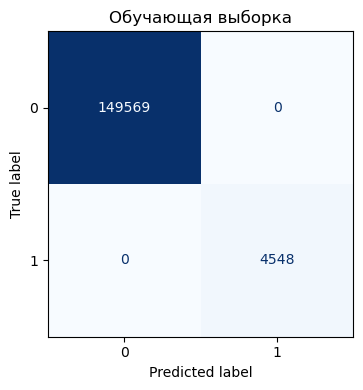

In [8]:
test(
    df=train_df,
    name='Обучающая выборка',
    model_pkl_path=root / 'models' / f'{model_name}.pkl',
    x_col='xtb_concat_3d',
    y_col='cryst',
)

Тестовая выборка
  F1        : 0.915
  ROC-AUC   : 0.986
  Precision : 0.994
  Recall    : 0.847


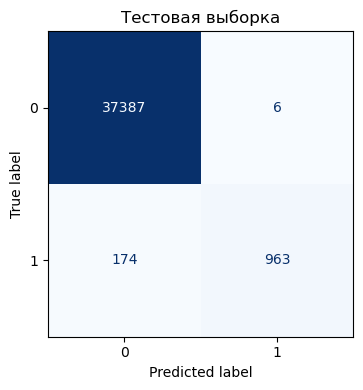

In [9]:
test(
    df=test_df,
    name='Тестовая выборка',
    model_pkl_path=root / 'models' / f'{model_name}.pkl',
    x_col='xtb_concat_3d',
    y_col='cryst',
)

На контрольном наборе производится сравнение двух типов признаков:
- на основе реальных 3D-геометрий
- на основе восстановленных геометрий

Цель — оценить, насколько реконструкция геометрии влияет на качество предсказания.

Вывод - влияет не сильно

Контрольная выборка: реальные 3D-геометрии
  F1        : 0.133
  ROC-AUC   : 0.675
  Precision : 0.074
  Recall    : 0.647
Контрольная выборка: геометрии из 2D
  F1        : 0.143
  ROC-AUC   : 0.644
  Precision : 0.081
  Recall    : 0.608


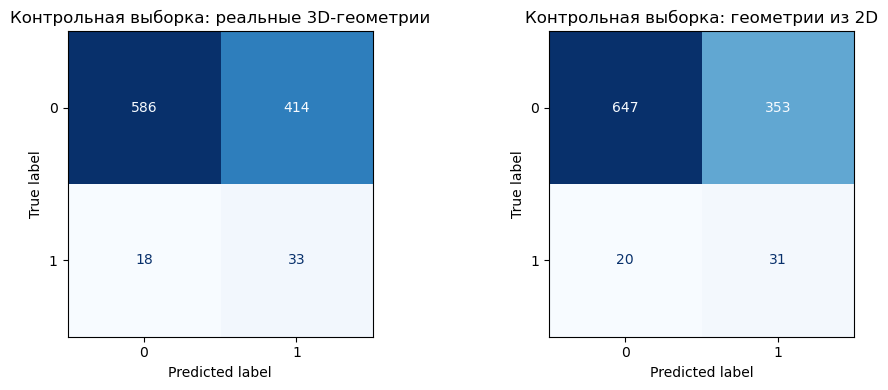

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

test(
    df=holdout_df,
    name='Контрольная выборка: реальные 3D-геометрии',
    model_pkl_path=root / 'models' / f'{model_name}.pkl',
    x_col='xtb_concat_3d',
    y_col='cryst',
    ax=axes[0]
)

test(
    df=holdout_df,
    name='Контрольная выборка: геометрии из 2D',
    model_pkl_path=root / 'models' / f'{model_name}.pkl',
    x_col='xtb_concat_rebuilt',
    y_col='cryst',
    ax=axes[1]
)

plt.tight_layout()
plt.show()

На дополнительном внешнем наборе оценивается обобщающая способность модели, так как здесь собраны системы, сильно отличающиеся от данных на трейне. Здесь она не справляется и нужен другой подход.


Экспериментальная выборка
  F1        : 0.000
  ROC-AUC   : 0.766
  Precision : 0.000
  Recall    : 0.000


/opt/anaconda3/envs/cocryst_base_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


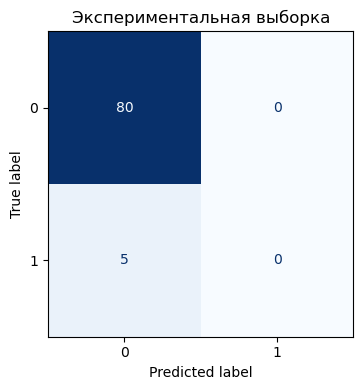

In [12]:
test(
    df=sulf_df,
    name='Экспериментальная выборка',
    model_pkl_path=root / 'models' / f'{model_name}.pkl',
    x_col='xtb_concat_rebuilt',
    y_col='cryst',
)